<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/Computer%20Vision/Generat%C3%ADv%20Modellek%20Stable%20Diffusion%20%C3%A9s%20DALLE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generatív Modellek: Stable Diffusion és DALL·E

A **diffúziós modellek** forradalmasították a képgenerálást. A Stable Diffusion és DALL·E a két legismertebb text-to-image rendszer.

## Alapötlet

```
"egy macska az űrben"  ──▶  [Text Encoder]  ──▶  ┐
                                                 │
Random zaj ──────────────────────────────────────┼──▶ [Diffusion Model] ──▶ Kép
                                                 │
                                        iteratív zajeltávolítás
```

## Tartalomjegyzék

1. Diffúziós folyamat
2. U-Net architektúra
3. Latent Diffusion (Stable Diffusion)
4. Text conditioning (CLIP)
5. Gyakorlati használat

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
torch.manual_seed(42)

## 1. Diffúziós folyamat

### Forward process (zajosítás)

$$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$$

ahol $\epsilon \sim \mathcal{N}(0, I)$ és $\bar{\alpha}_t$ a kumulatív zaj schedule.

### Reverse process (zajeltávolítás)

A modell megtanulja $\epsilon_\theta(x_t, t)$ - a hozzáadott zajt.

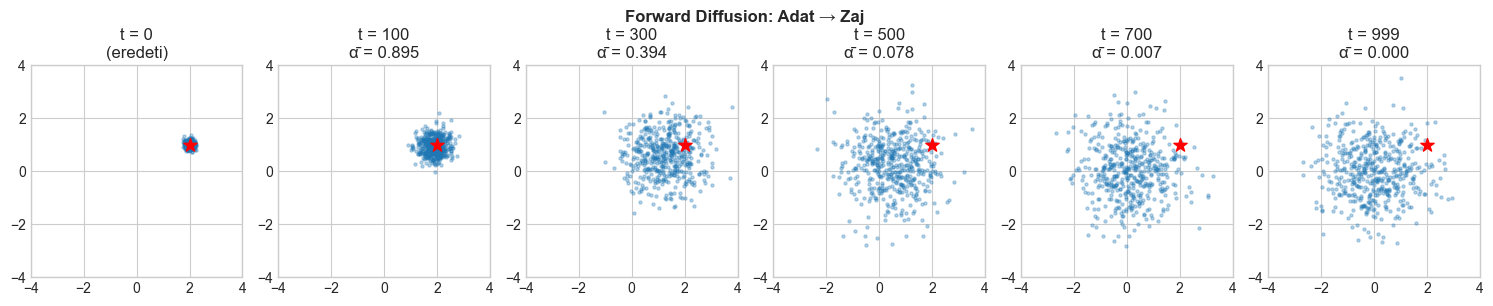

In [2]:
def visualize_diffusion_process():
    """Forward diffusion folyamat vizualizáció."""

    # Noise schedule
    T = 1000
    beta_start, beta_end = 0.0001, 0.02
    betas = np.linspace(beta_start, beta_end, T)
    alphas = 1 - betas
    alpha_bar = np.cumprod(alphas)

    # "Kép" (2D pont)
    x0 = np.array([2.0, 1.0])

    # Diffúziós trajektória
    timesteps = [0, 100, 300, 500, 700, 999]

    fig, axes = plt.subplots(1, len(timesteps), figsize=(15, 3))

    np.random.seed(42)

    for ax, t in zip(axes, timesteps):
        # x_t kiszámítása
        eps = np.random.randn(2)
        if t == 0:
            xt = x0
        else:
            xt = np.sqrt(alpha_bar[t]) * x0 + np.sqrt(1 - alpha_bar[t]) * eps

        # Monte Carlo mintavétel
        n_samples = 500
        samples = np.zeros((n_samples, 2))
        for i in range(n_samples):
            eps_i = np.random.randn(2)
            if t == 0:
                samples[i] = x0 + np.random.randn(2) * 0.1
            else:
                samples[i] = np.sqrt(alpha_bar[t]) * x0 + np.sqrt(1 - alpha_bar[t]) * eps_i

        ax.scatter(samples[:, 0], samples[:, 1], alpha=0.3, s=5)
        ax.scatter([x0[0]], [x0[1]], c='red', s=100, marker='*', label='x₀')
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_title(f't = {t}\nᾱ = {alpha_bar[t]:.3f}' if t > 0 else 't = 0\n(eredeti)')
        ax.set_aspect('equal')

    plt.suptitle('Forward Diffusion: Adat → Zaj', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_diffusion_process()

C:\Users\Balint\AppData\Local\Temp\ipykernel_20556\1384787849.py:38: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


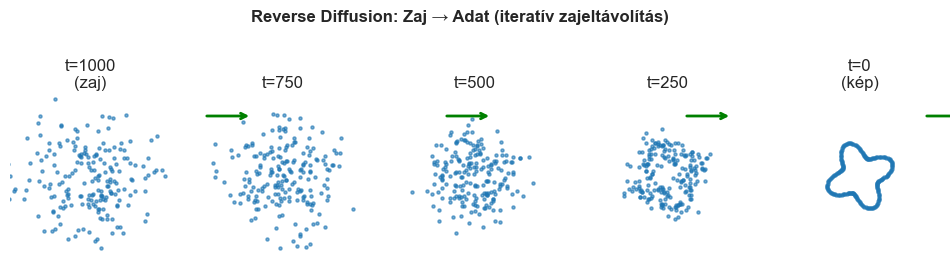

In [3]:
# Reverse process szimulálása
def visualize_reverse_process():
    """Reverse diffusion (zajeltávolítás)."""

    steps = ['t=1000\n(zaj)', 't=750', 't=500', 't=250', 't=0\n(kép)']

    fig, axes = plt.subplots(1, 5, figsize=(12, 3))

    # Szimulált zajeltávolítás
    np.random.seed(123)

    for i, (ax, step) in enumerate(zip(axes, steps)):
        # Egyre kevesebb zaj
        noise_level = 1 - i/4

        # Egyszerű "kép" szimulálása (kör alakú minta)
        n = 200
        theta = np.linspace(0, 2*np.pi, n)
        r = 1 + 0.3 * np.sin(4*theta)
        x = r * np.cos(theta) + np.random.randn(n) * noise_level
        y = r * np.sin(theta) + np.random.randn(n) * noise_level

        ax.scatter(x, y, s=5, alpha=0.6)
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_title(step)
        ax.set_aspect('equal')
        ax.axis('off')

    # Nyilak
    for i in range(4):
        plt.annotate('', xy=(0.21 + i*0.2, 0.5), xytext=(0.17 + i*0.2, 0.5),
                    xycoords='figure fraction',
                    arrowprops=dict(arrowstyle='->', color='green', lw=2))

    plt.suptitle('Reverse Diffusion: Zaj → Adat (iteratív zajeltávolítás)',
                fontsize=12, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

visualize_reverse_process()

## 2. U-Net architektúra

A diffúziós modell gerince egy **U-Net**, amely megtanulja a hozzáadott zajt.

```
        Encoder                    Decoder
    ┌─────────────┐            ┌─────────────┐
x_t │  Conv + RB  │────────────│  Conv + RB  │ ε_θ
    │      ↓      │            │      ↑      │
    │  Downsample │            │  Upsample   │
    │      ↓      │            │      ↑      │
    │  Conv + RB  │────────────│  Conv + RB  │
    │      ↓      │            │      ↑      │
    └──────┬──────┘            └──────┴──────┘
           └────▶ Bottleneck ◀─────────┘
                 (+ Time emb)
                 (+ Text emb)        
```

In [4]:
class TimeEmbedding(nn.Module):
    """Sinusoidal time embedding."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t.unsqueeze(1) * emb.unsqueeze(0)
        return torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)


class SimpleUNet(nn.Module):
    """Egyszerűsített U-Net diffúzióhoz."""
    def __init__(self, in_channels=3, time_dim=64):
        super().__init__()

        self.time_emb = TimeEmbedding(time_dim)
        self.time_mlp = nn.Linear(time_dim, 64)

        # Encoder
        self.enc1 = nn.Conv2d(in_channels, 32, 3, 1, 1)
        self.enc2 = nn.Conv2d(32, 64, 3, 2, 1)  # downsample

        # Bottleneck
        self.bottleneck = nn.Conv2d(64, 64, 3, 1, 1)

        # Decoder
        self.dec2 = nn.ConvTranspose2d(64, 32, 4, 2, 1)  # upsample
        self.dec1 = nn.Conv2d(64, in_channels, 3, 1, 1)  # skip connection

    def forward(self, x, t):
        # Time embedding
        t_emb = self.time_emb(t.float())
        t_emb = self.time_mlp(t_emb)

        # Encoder
        h1 = F.relu(self.enc1(x))
        h2 = F.relu(self.enc2(h1))

        # Bottleneck + time
        h = self.bottleneck(h2)
        # Time hozzáadása (egyszerűsített)
        h = h + t_emb[:, :, None, None].expand(-1, -1, h.size(2), h.size(3))[:, :64]

        # Decoder with skip
        h = F.relu(self.dec2(h))
        h = torch.cat([h, h1], dim=1)  # skip connection
        out = self.dec1(h)

        return out

# Teszt
unet = SimpleUNet()
x = torch.randn(2, 3, 32, 32)
t = torch.tensor([100, 500])
pred_noise = unet(x, t)
print(f"Input: {x.shape} → Predicted noise: {pred_noise.shape}")

Input: torch.Size([2, 3, 32, 32]) → Predicted noise: torch.Size([2, 3, 32, 32])


## 3. Latent Diffusion (Stable Diffusion)

A **Latent Diffusion Model** (LDM) ötlete: ne pixel térben, hanem **latent térben** diffundáljunk!

```
┌────────────────────────────────────────────────────────────┐
│                                                            │
│  Kép ──▶ [Encoder] ──▶ Latent ──▶ [Diffusion] ──▶ Latent  │
│    ↑                     (kisebb)      (U-Net)       │     │
│    │                                                 ↓     │
│    └─────────────────────────────── [Decoder] ◀──────┘     │
│                                                            │
└────────────────────────────────────────────────────────────┘
```

### Előnyök

| Pixel Diffusion | Latent Diffusion |
|-----------------|------------------|
| 512×512×3 = 786K | 64×64×4 = 16K |
| Lassú | 48× gyorsabb |
| Sok GPU | Kevesebb GPU |

In [5]:
class VAE_Encoder(nn.Module):
    """Egyszerűsített VAE encoder a latent térhez."""
    def __init__(self, latent_dim=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(128, latent_dim, 3, 1, 1),
        )

    def forward(self, x):
        return self.encoder(x)

class VAE_Decoder(nn.Module):
    """Egyszerűsített VAE decoder."""
    def __init__(self, latent_dim=4):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.decoder(z)

# Demonstráció
encoder = VAE_Encoder()
decoder = VAE_Decoder()

image = torch.randn(1, 3, 64, 64)  # Eredeti kép
latent = encoder(image)             # Latent reprezentáció
reconstructed = decoder(latent)     # Rekonstrukció

print(f"Eredeti kép: {image.shape}")
print(f"Latent tér: {latent.shape} ({latent.numel()} elem)")
print(f"Rekonstruált: {reconstructed.shape}")
print(f"\nKompresszió: {image.numel() / latent.numel():.1f}×")

Eredeti kép: torch.Size([1, 3, 64, 64])
Latent tér: torch.Size([1, 4, 16, 16]) (1024 elem)
Rekonstruált: torch.Size([1, 3, 64, 64])

Kompresszió: 12.0×


## 4. Text conditioning

A szöveges prompt a **cross-attention** mechanizmuson keresztül irányítja a generálást.

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d}}\right)V$$

ahol:
- $Q$ = U-Net features
- $K, V$ = Text embeddings (CLIP)

In [6]:
class CrossAttention(nn.Module):
    """Cross-attention text conditioning."""
    def __init__(self, query_dim, context_dim, heads=4):
        super().__init__()
        self.heads = heads
        self.head_dim = query_dim // heads

        self.to_q = nn.Linear(query_dim, query_dim)
        self.to_k = nn.Linear(context_dim, query_dim)
        self.to_v = nn.Linear(context_dim, query_dim)
        self.to_out = nn.Linear(query_dim, query_dim)

    def forward(self, x, context):
        """x: [B, N, D], context: [B, M, C]"""
        B = x.shape[0]

        q = self.to_q(x)        # Query from image features
        k = self.to_k(context)  # Key from text
        v = self.to_v(context)  # Value from text

        # Multi-head attention
        q = q.view(B, -1, self.heads, self.head_dim).transpose(1, 2)
        k = k.view(B, -1, self.heads, self.head_dim).transpose(1, 2)
        v = v.view(B, -1, self.heads, self.head_dim).transpose(1, 2)

        attn = (q @ k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        attn = F.softmax(attn, dim=-1)

        out = (attn @ v).transpose(1, 2).reshape(B, -1, q.shape[-1] * self.heads)
        return self.to_out(out)

# Példa
cross_attn = CrossAttention(query_dim=64, context_dim=512)

# Szimulált U-Net features és CLIP text embedding
unet_features = torch.randn(1, 16, 64)  # 16 spatial position, 64 dim
text_embedding = torch.randn(1, 10, 512)  # 10 token, 512 dim (CLIP)

conditioned = cross_attn(unet_features, text_embedding)
print(f"U-Net features: {unet_features.shape}")
print(f"Text embedding: {text_embedding.shape}")
print(f"After cross-attn: {conditioned.shape}")

U-Net features: torch.Size([1, 16, 64])
Text embedding: torch.Size([1, 10, 512])
After cross-attn: torch.Size([1, 16, 64])


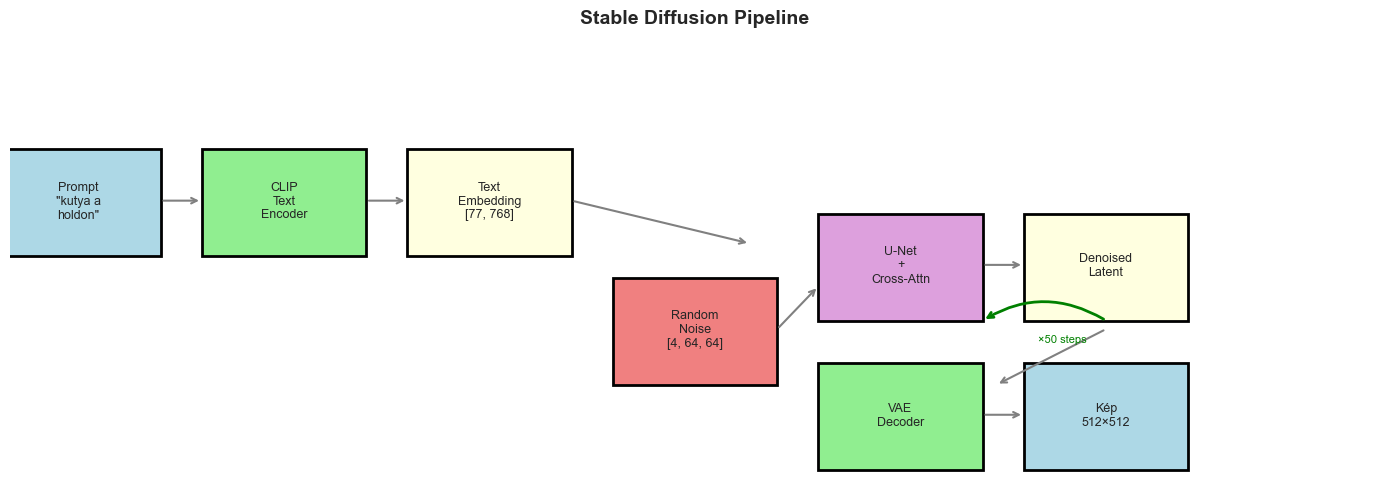

In [7]:
def visualize_generation_pipeline():
    """Teljes text-to-image pipeline."""

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.axis('off')

    # Boxes
    boxes = [
        (0.05, 0.6, 'Prompt\n"kutya a\nholdon"', 'lightblue'),
        (0.2, 0.6, 'CLIP\nText\nEncoder', 'lightgreen'),
        (0.35, 0.6, 'Text\nEmbedding\n[77, 768]', 'lightyellow'),
        (0.5, 0.3, 'Random\nNoise\n[4, 64, 64]', 'lightcoral'),
        (0.65, 0.45, 'U-Net\n+\nCross-Attn', 'plum'),
        (0.8, 0.45, 'Denoised\nLatent', 'lightyellow'),
        (0.65, 0.1, 'VAE\nDecoder', 'lightgreen'),
        (0.8, 0.1, 'Kép\n512×512', 'lightblue'),
    ]

    for x, y, text, color in boxes:
        ax.add_patch(plt.Rectangle((x-0.06, y-0.08), 0.12, 0.25,
                                   facecolor=color, edgecolor='black', lw=2))
        ax.text(x, y+0.05, text, ha='center', va='center', fontsize=9)

    # Arrows
    arrows = [
        (0.11, 0.65, 0.14, 0.65),
        (0.26, 0.65, 0.29, 0.65),
        (0.41, 0.65, 0.54, 0.55),  # to U-Net
        (0.56, 0.35, 0.59, 0.45),  # noise to U-Net
        (0.71, 0.5, 0.74, 0.5),    # U-Net to denoised
        (0.8, 0.35, 0.72, 0.22),   # to decoder
        (0.71, 0.15, 0.74, 0.15),  # decoder to image
    ]

    for x1, y1, x2, y2 in arrows:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                   arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

    # Loop arrow
    ax.annotate('', xy=(0.71, 0.37), xytext=(0.8, 0.37),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3',
                             color='green', lw=2))
    ax.text(0.75, 0.32, '×50 steps', fontsize=8, color='green')

    plt.title('Stable Diffusion Pipeline', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

visualize_generation_pipeline()

## 5. Gyakorlati használat

### Stable Diffusion Python-ban

```python
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5"
).to("cuda")

image = pipe(
    prompt="a cat astronaut on the moon, digital art",
    num_inference_steps=50,
    guidance_scale=7.5
).images[0]
```

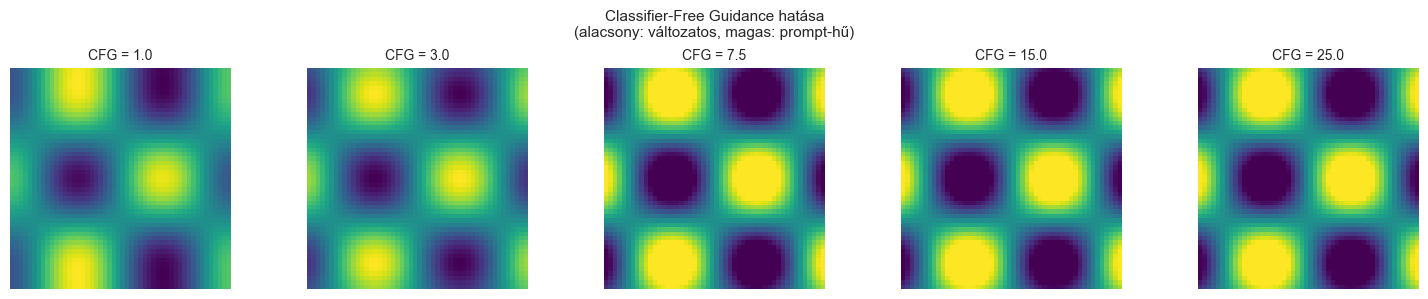


💡 Tipikus CFG értékek:
  1.0 - Nincs guidance (változatos, de prompt-tól eltérhet)
  7.5 - Alapértelmezett (jó egyensúly)
  15+ - Erős prompt követés (túlszaturált lehet)


In [8]:
# Guidance scale hatása
def visualize_cfg_effect():
    """Classifier-Free Guidance (CFG) hatása."""

    guidance_scales = [1.0, 3.0, 7.5, 15.0, 25.0]

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))

    for ax, cfg in zip(axes, guidance_scales):
        # Szimulált hatás
        np.random.seed(42)

        # Alacsony CFG: elmosódott, változatos
        # Magas CFG: éles, de kevésbé változatos
        blur = max(0.1, 2 / cfg)
        contrast = min(1.5, cfg / 5)

        # Egyszerű minta generálása
        x = np.linspace(-2, 2, 50)
        y = np.linspace(-2, 2, 50)
        X, Y = np.meshgrid(x, y)
        Z = np.sin(X*2) * np.cos(Y*2)

        # Blur és kontraszt szimuláció
        from scipy.ndimage import gaussian_filter
        Z_blurred = gaussian_filter(Z, sigma=blur*2)
        Z_contrast = np.clip(Z_blurred * contrast, -1, 1)

        ax.imshow(Z_contrast, cmap='viridis', extent=[-2, 2, -2, 2])
        ax.set_title(f'CFG = {cfg}', fontsize=10)
        ax.axis('off')

    plt.suptitle('Classifier-Free Guidance hatása\n(alacsony: változatos, magas: prompt-hű)',
                fontsize=11)
    plt.tight_layout()
    plt.show()

    print("\n💡 Tipikus CFG értékek:")
    print("  1.0 - Nincs guidance (változatos, de prompt-tól eltérhet)")
    print("  7.5 - Alapértelmezett (jó egyensúly)")
    print("  15+ - Erős prompt követés (túlszaturált lehet)")

try:
    from scipy.ndimage import gaussian_filter
    visualize_cfg_effect()
except ImportError:
    print("scipy nem elérhető, de CFG vizualizáció opcionális")

## Összefoglalás

### Diffúziós modellek

1. **Forward**: Adat → Zaj (fokozatos zajhozzáadás)
2. **Reverse**: Zaj → Adat (tanult zajeltávolítás)
3. **Training**: ε-prediction (zaj becslése)

### Stable Diffusion komponensek

| Komponens | Funkció |
|-----------|----------|
| VAE Encoder | Kép → Latent (kompresszió) |
| CLIP Text Encoder | Prompt → Embedding |
| U-Net | Zajeltávolítás + Cross-attention |
| VAE Decoder | Latent → Kép |

### Kulcs hiperparaméterek

- **Steps** (20-50): Több lépés = jobb minőség, lassabb
- **CFG Scale** (7-12): Prompt követés erőssége
- **Seed**: Reprodukálhatóság